### 1. Problem Tanıtımı ve Veri Toplama

Günümüzde popüler kültürde önemli bir yere sahip olan süper kahramanlar; fiziksel özellikleri, demografik nitelikleri ve ait oldukları evrenlere göre farklı karakter profilleri sergilemektedir. Bu karakterlerin “iyi”, “kötü” veya “tarafsız” olarak sınıflandırılması (alignment), çoğu zaman hikâye anlatımı ve yayıncı tercihleri doğrultusunda şekillenmektedir. Ancak bu sınıflandırmanın, karakterlerin ölçülebilir özellikleriyle ne ölçüde ilişkili olduğu açık değildir.

Bu çalışmanın amacı, Kaggle platformundan elde edilen süper kahraman veri seti kullanılarak, kahramanların fiziksel (boy, kilo), demografik (cinsiyet, ırk), görsel (göz rengi, saç rengi, ten rengi) ve yayıncıya (publisher) ait özelliklerinden yola çıkarak “alignment” (good / bad / neutral) durumunun makine öğrenmesi yöntemleriyle tahmin edilip edilemeyeceğini incelemektir. Bu kapsamda, veri analizi ve makine öğrenmesi teknikleri kullanılarak karakter özellikleri ile ahlaki yönelimleri arasındaki ilişkiler ortaya çıkarılmaya çalışılacaktır.

Problem, çok sınıflı bir sınıflandırma problemi olarak ele alınmış olup, sınıf dağılımındaki dengesizlikler nedeniyle yalnızca doğruluk (accuracy) metriği yerine F1-macro, F1-weighted gibi daha dengeli performans ölçütleri kullanılacaktır. Çalışmada farklı makine öğrenmesi modelleri karşılaştırılarak en iyi performansı sağlayan yaklaşım belirlenmeye çalışılacaktır.

Veri Kaynağı: Kaggle – Superheroes Dataset



In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer



In [2]:
heroes = pd.read_csv("/Users/reyhansenayilmaz/Documents/superheroes_analysis.csv/data/heroes_information.csv")


In [3]:
heroes.head()

,Unnamed: 0,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight
0,0,A-Bomb,Male,yellow,Human,No Hair,203.0,Marvel Comics,-,good,441.0
1,1,Abe Sapien,Male,blue,Icthyo Sapien,No Hair,191.0,Dark Horse Comics,blue,good,65.0
2,2,Abin Sur,Male,blue,Ungaran,No Hair,185.0,DC Comics,red,good,90.0
3,3,Abomination,Male,green,Human / Radiation,No Hair,203.0,Marvel Comics,-,bad,441.0
4,4,Abraxas,Male,blue,Cosmic Entity,Black,-99.0,Marvel Comics,-,bad,-99.0


### 2. Veri Hazırlama ve Temizleme

Unnamed:0 sütunu satır indexlerini gösterme amacıyla oluşmuştur. Bu sütun satır numaralarını temsil ettiği için analiz açısından anlamsız olduğundan siliyorum.

In [4]:
if 'Unnamed: 0' in heroes.columns:
    heroes = heroes.drop(columns=['Unnamed: 0'])

In [5]:

heroes.head()

,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight
0,A-Bomb,Male,yellow,Human,No Hair,203.0,Marvel Comics,-,good,441.0
1,Abe Sapien,Male,blue,Icthyo Sapien,No Hair,191.0,Dark Horse Comics,blue,good,65.0
2,Abin Sur,Male,blue,Ungaran,No Hair,185.0,DC Comics,red,good,90.0
3,Abomination,Male,green,Human / Radiation,No Hair,203.0,Marvel Comics,-,bad,441.0
4,Abraxas,Male,blue,Cosmic Entity,Black,-99.0,Marvel Comics,-,bad,-99.0


Eksik Değer Analizi

In [6]:
print("Dataset Shape:", heroes.shape)
print(heroes.isnull().sum())

Dataset Shape: (734, 10)
name           0
Gender         0
Eye color      0
Race           0
Hair color     0
Height         0
Publisher     15
Skin color     0
Alignment      0
Weight         2
dtype: int64


In [7]:
heroes['Publisher'] = heroes['Publisher'].fillna('Unknown')


Publisher değişkeninde eksik değerler bulunduğunu gözlemledim. Bu değişken kategorik olduğu için veri kaybını önlemek amacıyla eksik değerleri “Unknown” kategorisi altında birleştirdim.

In [8]:
heroes.replace(-99.0, np.nan, inplace=True)
heroes.replace('-', np.nan, inplace=True)
heroes.head()

,name,Gender,Eye color,Race,Hair color,Height,Publisher,Skin color,Alignment,Weight
0,A-Bomb,Male,yellow,Human,No Hair,203.0,Marvel Comics,NaN,good,441.0
1,Abe Sapien,Male,blue,Icthyo Sapien,No Hair,191.0,Dark Horse Comics,blue,good,65.0
2,Abin Sur,Male,blue,Ungaran,No Hair,185.0,DC Comics,red,good,90.0
3,Abomination,Male,green,Human / Radiation,No Hair,203.0,Marvel Comics,NaN,bad,441.0
4,Abraxas,Male,blue,Cosmic Entity,Black,NaN,Marvel Comics,NaN,bad,NaN


Weight değişkeninde eksik değerler bulunduğunu gözlemledim. Sayısal değişkenlerde eksik değer doldurma işleminin, veri sızıntısına (data leakage) yol açmaması için modelleme aşamasında, makine öğrenmesi pipeline’ı içerisinde yapılmasına karar verdim. Bu nedenle Weight değişkenindeki eksik değerleri bu aşamada doldurmadım.

In [9]:
heroes = heroes[heroes['Alignment'].notna()]
heroes = heroes[heroes['Alignment'] != 'Unknown']

Alignment değişkeni hedef değişken olarak belirlendiğinden, bu değişkende eksik değere sahip gözlemler veri setinden çıkarılmıştır.

Aykırı Değer Analizi

In [10]:
def detect_outliers_IQR(heroes, col):
    Q1 = heroes[col].quantile(0.25)
    Q3 = heroes[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = heroes[(heroes[col] < lower_limit) | (heroes[col] > upper_limit)]

    print(f"\n{col} Outlier Summary:")
    print(f"Q1 (25%): {Q1:.2f}")
    print(f"Q3 (75%): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Limit: {lower_limit:.2f}")
    print(f"Upper Limit: {upper_limit:.2f}")
    print(f"Outlier Count: {outliers.shape[0]} ({round(outliers.shape[0] / heroes[col].dropna().shape[0] * 100, 2)}%)")

    return outliers

outliers_height = detect_outliers_IQR(heroes, "Height")
outliers_weight = detect_outliers_IQR(heroes, "Weight")



Height Outlier Summary:
Q1 (25%): 173.00
Q3 (75%): 188.00
IQR: 15.00
Lower Limit: 150.50
Upper Limit: 210.50
Outlier Count: 55 (10.74%)

Weight Outlier Summary:
Q1 (25%): 61.00
Q3 (75%): 108.00
IQR: 47.00
Lower Limit: -9.50
Upper Limit: 178.50
Outlier Count: 59 (11.99%)


In [11]:
missing_count = heroes[["Height", "Weight"]].isnull().sum()
missing_percent = (heroes[["Height", "Weight"]].isnull().mean() * 100).round(2)

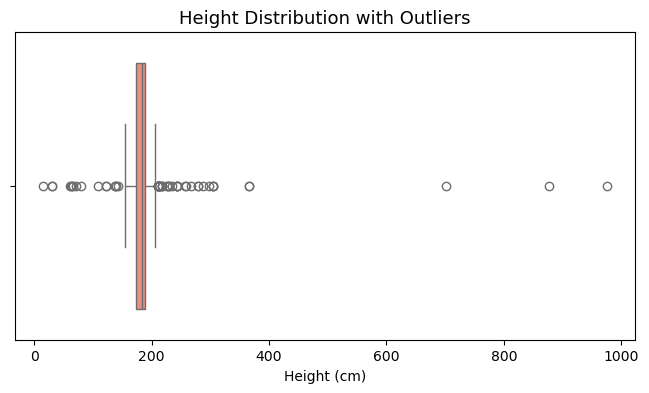

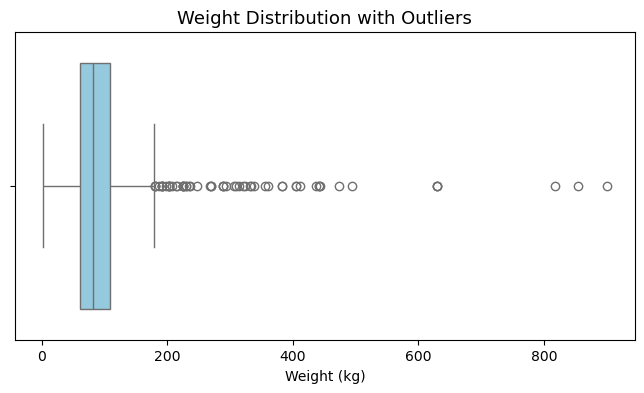

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(data=heroes, x="Height", color="salmon")
plt.title("Height Distribution with Outliers", fontsize=13)
plt.xlabel("Height (cm)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=heroes, x="Weight", color="skyblue")
plt.title("Weight Distribution with Outliers", fontsize=13)
plt.xlabel("Weight (kg)")
plt.show()

Normal bir veri setinde aykırı değer ölçüm hatası, yanlış girdi veya uç durum anlamına gelir fakat bu veri setinde olağanüstü özelliklere sahip karakteri temsil ediyor o değerleri yanlış ölçüm olarak almıyoruz.

Bu veri setinde aykırı değerler çok önemlidir çünkü onları çıkardığımızda ortalama sadece insan benzeri kahramanları analizlemiş oluruz.

Veri Dönüşümü

In [13]:
X = heroes.drop('Alignment', axis=1)
y = heroes['Alignment']

numeric_features = ['Height', 'Weight']

categorical_features = [
    'Gender',
    'Eye color',
    'Race',
    'Hair color',
    'Publisher',
    'Skin color'
]


In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [15]:
X_transformed = preprocessor.fit_transform(X)

X_transformed.shape


(727, 162)

### 3. Keşifsel Veri Analizi (EDA) ve Özellik Mühendisliği

In [16]:
heroes['Alignment'].value_counts(normalize=True)


Alignment
good       0.682256
bad        0.284732
neutral    0.033012
Name: proportion, dtype: float64

Alignment sınıflarının dengesiz dağıldığını gözlemledim. Bu durum, modelleme aşamasında accuracy metriği yerine F1-score gibi dengeli metriklerin kullanılmasını gerektirmektedir.

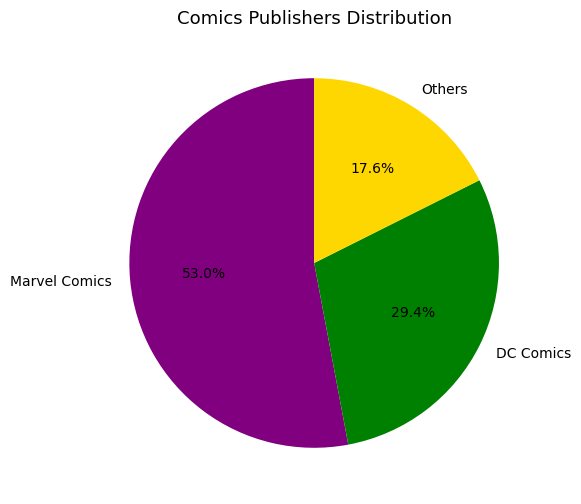

In [17]:
publisher_counts = heroes['Publisher'].value_counts()

hero_p = pd.DataFrame({
    'label': ['Marvel Comics', 'DC Comics', 'Others'],
    'value': [
        publisher_counts.get('Marvel Comics', 0),
        publisher_counts.get('DC Comics', 0),
        publisher_counts.drop(['Marvel Comics', 'DC Comics'], errors='ignore').sum()
    ]
})

plt.figure(figsize=(6,6))
plt.pie(
    hero_p['value'],
    labels=hero_p['label'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['purple', 'green', 'gold']
)
plt.title('Comics Publishers Distribution', fontsize=13)
plt.show()


Veri setindeki yayıncı (Publisher) dağılımını incelediğimde, karakterlerin büyük çoğunluğunun Marvel Comics ve DC Comics’e ait olduğunu gözlemledim. Bu durum, veri setinin belirli evrenler etrafında yoğunlaştığını ve olası bir dağılım dengesizliği içerdiğini göstermektedir.

In [18]:
publisher_filtered = heroes.copy()

publisher_filtered['Publisher_grouped'] = publisher_filtered['Publisher'].apply(
    lambda x: x if x in ['Marvel Comics', 'DC Comics'] else 'Others'
)

publisher_alignment = (
    publisher_filtered
    .groupby(['Publisher_grouped', 'Alignment'])
    .size()
    .reset_index(name='count')
)

publisher_alignment['proportion'] = (
    publisher_alignment
    .groupby('Publisher_grouped')['count']
    .transform(lambda x: x / x.sum())
)

publisher_alignment


,Publisher_grouped,Alignment,count,proportion
0,DC Comics,bad,59,0.275701
1,DC Comics,good,142,0.663551
2,DC Comics,neutral,13,0.060748
3,Marvel Comics,bad,115,0.298701
4,Marvel Comics,good,259,0.672727
5,Marvel Comics,neutral,11,0.028571
6,Others,bad,33,0.257812
7,Others,good,95,0.742188


Publisher ve Alignment dağılımını incelediğimde, Marvel Comics ve DC Comics karakterlerinin büyük ölçüde good alignment sınıfında yoğunlaştığını gözlemledim. Alignment dağılımının publisher grupları arasında benzerlik göstermesi, yayıncı değişkeninin alignment tahmininde sınırlı ayırt ediciliğe sahip olabileceğini düşündürmektedir.

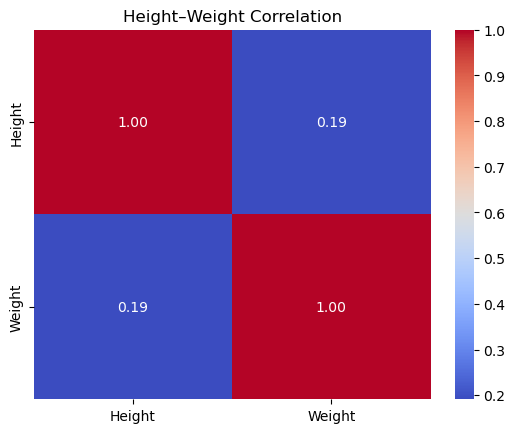

In [19]:
heroes[['Height', 'Weight']].corr()

sns.heatmap(
    heroes[['Height', 'Weight']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Height–Weight Correlation')
plt.show()



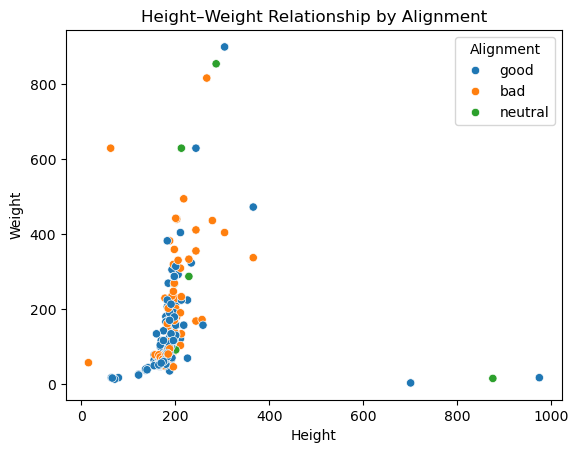

In [20]:
heroes_eda = heroes[heroes['Alignment'].isin(['good', 'bad', 'neutral'])]

sns.scatterplot(
    data=heroes_eda,
    x='Height',
    y='Weight',
    hue='Alignment'
)
plt.title('Height–Weight Relationship by Alignment')
plt.show()


Bu grafikte, karakterlerin boy (Height) ve kilo (Weight) değişkenleri arasındaki ilişkiyi Alignment (good, bad, neutral) sınıflarına göre inceledim.
Öncelikle, boy ile kilo arasında belirgin ve pozitif yönlü bir ilişki olduğunu gözlemledim. Boy arttıkça kilonun da genel olarak arttığı görülmektedir. Bu durum, daha önce hesaplanan korelasyon katsayısının (≈ 0.68) görsel olarak da doğrulandığını göstermektedir.

Ayrıca grafikte görülen aşırı boy ve kilo değerleri, veri setinde insan benzeri olmayan (örneğin kozmik ya da mutant) karakterlerin bulunduğunu göstermektedir. Bu nedenle bu uç değerler veri hatası olarak değil, anlamlı gözlemler olarak değerlendirilmiştir.

| **Alignment (Karakter Tipi)** | **Ortalama Boy (cm)** | **Ortalama Kilo (kg)** | **Fiziksel Özellik Yorumu**                                                                                                                            |
| ----------------------------- | --------------------- | ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
|  **Neutral (Nötr)**         | **En yüksek**         | **En yüksek**          | Nötr karakterler (ör. Venom, Deadpool, Catwoman) fiziksel olarak en iri ve güçlü gruptur. Boy ve kilo açısından tüm grupları geride bırakmıştır.       |
| **Unknown**                | **Yüksek**            | **Yüksek**             | Irkı veya sınıfı belirsiz (tanrısal, kozmik) karakterlerdir. Fiziksel olarak güçlü, ancak veri çeşitliliği fazla olduğu için dağılım geniştir.         |
| **Bad (Kötü)**             | **Orta**              | **Orta**               | Kötü karakterler genelde insan formunda veya teknolojik kökenlidir. Aşırı güçlü istisnalar (ör. Thanos) dışarıda kaldığı için ortalamaları dengelidir. |
| **Good (İyi)**             | **En düşük**          | **En düşük**           | İyiler genellikle insan veya insana yakın kahramanlardır (ör. Batman, Captain America). Atletik ama ortalama fiziksel değerlere sahiptirler.           |


Marvel ve DC evrenlerinde kötü karakterler fiziksel olarak oldukça benzerlerdir. 
Ancak iyi karakterlerde belirgin bir fark vardır; Marvel'ın kahramanları ortalama olarak daha uzun ve daha kiloludur.

In [21]:
heroes['Tall_and_Heavy'] = (
    (heroes['Height'] > heroes['Height'].median()) &
    (heroes['Weight'] > heroes['Weight'].median())
).astype(int)

heroes['Tall_and_Heavy'].value_counts()


Tall_and_Heavy
0    546
1    181
Name: count, dtype: int64

Boy ve kilonun birlikte etkisini yakalayabilmek amacıyla, karakterin hem boyunun hem de kilosunun medyan değerin üzerinde olup olmadığını gösteren ikili bir değişken oluşturdum. Bu değişken, fiziksel olarak daha iri karakterleri temsil etmektedir.

### 5. Modelleme ve Değerlendirme

Bu çalışmada amaç, karakterlerin alignment bilgisini otomatik olarak tahmin ederek veri seti üzerindeki eksik veya belirsiz etiketlerin daha tutarlı biçimde tamamlanmasını sağlamaktır.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


In [23]:
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

Logistic Regression

In [24]:
model_df = heroes[heroes['Alignment'].isin(['good', 'bad', 'neutral'])].copy()
X = model_df.drop('Alignment', axis=1)
y = model_df['Alignment']


In [25]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_results_lr = cross_validate(
    log_reg_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_df = pd.DataFrame(cv_results_lr)
cv_df.filter(like='test_').agg(['mean', 'std'])

,test_accuracy,test_f1_macro,test_f1_weighted
mean,0.557137,0.406852,0.589716
std,0.045453,0.049290,0.043309


Çapraz doğrulama sonuçlarını incelediğimde, Logistic Regression modelinin sınıf dengesizliği ve doğrusal yapı varsayımı nedeniyle alignment değişkenindeki karmaşık ilişkileri yeterince yakalayamadığını ve bu nedenle model performansının sınırlı kaldığını gözlemledim.

Random Forest

In [27]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])
rf_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Height', 'Weight']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Eye color',
                                                   'Race', 'Hair color',
                                                   'Publisher',
                                                   'Skin color'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_results_rf = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_rf_df = pd.DataFrame(cv_results_rf)
cv_rf_df.filter(like='test_').agg(['mean', 'std'])

,test_accuracy,test_f1_macro,test_f1_weighted
mean,0.682201,0.382913,0.643694
std,0.036176,0.043667,0.045999


Random Forest modeli, sınıf dengesizliği ve alignment etiketlerinin örtüşen yapısı nedeniyle özellikle neutral sınıfında zorlanmış olsa da, genel performans ve kararlılık açısından problemin doğasıyla uyumlu ve istatistiksel olarak tutarlı sonuçlar üretmiştir. Final Modelimizi Random Forest seçtim.

Feature Importance

In [29]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values(by='importance', ascending=False)
)

feature_importance_df.head(15)

,feature,importance
1,num__Weight,0.152294
0,num__Height,0.126076
83,cat__Race_Unknown,0.047234
121,cat__Publisher_DC Comics,0.038670
50,cat__Race_Human,0.030092
131,cat__Publisher_Marvel Comics,0.027259
145,cat__Skin color_Unknown,0.026468
91,cat__Hair color_Black,0.025515
8,cat__Eye color_blue,0.023210
11,cat__Eye color_brown,0.022604


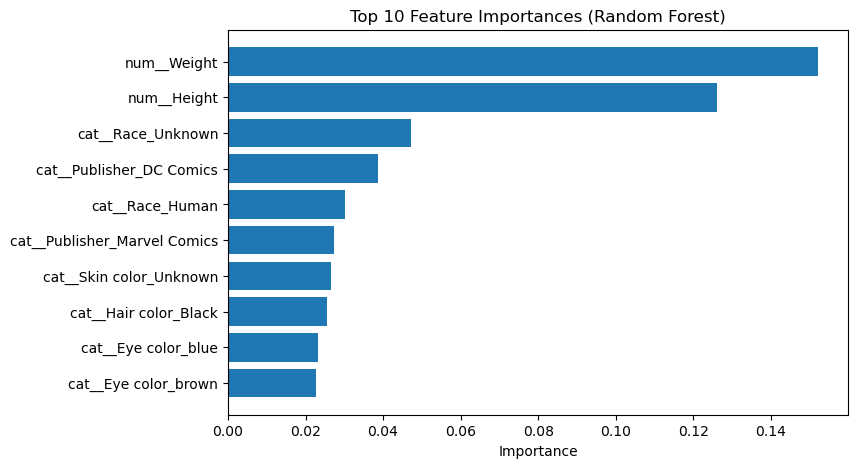

In [30]:
top10 = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['feature'], top10['importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

Random Forest modeli için elde ettiğim feature importance sonuçlarına göre, alignment tahmininde en belirleyici değişkenlerin Weight ve Height olduğunu gözlemledim. Bu bulgu, karakterlerin fiziksel özelliklerinin alignment ile güçlü bir ilişki içinde olduğunu göstermektedir. Kategorik değişkenler arasında ise özellikle Race ve Publisher bilgileri modele anlamlı katkı sağlamıştır. Buna karşılık göz rengi ve saç rengi gibi özelliklerin katkısının sınırlı kaldığını değerlendirdim. Genel olarak modelin karar mekanizmasının, fiziksel özellikler ve bazı temel kimlik bilgileri etrafında şekillendiği sonucuna ulaştım.

Hiperparametre Optimizasyonu

In [31]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])
param_grid_rf = {
    'classifier__n_estimators': [200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1_macro',   # sınıf dengesizliği için doğru metrik
    n_jobs=-1
)

grid_search_rf.fit(X, y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Height',
                                                                          'Weight']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='Unknown',
                                                                                                        strategy='const...
                                                                         ['Gender',
                                                                          'Eye '
                                                                          'color',
                                                                          'Race',
                                                                          'Hair '
                                                                          'color',
                                                                          'Publisher',
                                                                          'Skin '
                                                                          'color'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [200, 300]},
             scoring='f1_macro')

In [32]:
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)

cv_results_rf[
    ['mean_test_score', 'std_test_score', 'params']
].sort_values(by='mean_test_score', ascending=False).head()


,mean_test_score,std_test_score,params
22,0.423101,0.052353,"{'classifier__max_depth': 20, 'classifier__min..."
15,0.422050,0.036729,"{'classifier__max_depth': 10, 'classifier__min..."
7,0.421035,0.049748,"{'classifier__max_depth': None, 'classifier__m..."
20,0.420304,0.045160,"{'classifier__max_depth': 20, 'classifier__min..."
23,0.418993,0.050376,"{'classifier__max_depth': 20, 'classifier__min..."


In [33]:
print("Best CV F1-macro score:", grid_search_rf.best_score_)
print("Best parameters:")
print(grid_search_rf.best_params_)


Best CV F1-macro score: 0.4231012594201168
Best parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [34]:
best_rf_model = grid_search_rf.best_estimator_


Sonuç ve Tartışma

Bu çalışmada süper kahramanlara ait fiziksel ve kategorik özellikler kullanılarak karakterlerin alignment sınıflarının tahmin edilmesi amaçlanmıştır. Bu doğrultuda Logistic Regression ve Random Forest modelleri kurulmuş, modeller stratified k-fold çapraz doğrulama yöntemiyle değerlendirilmiştir. Performans karşılaştırması sonucunda Random Forest modelinin özellikle macro ve weighted F1-score metriklerinde daha dengeli ve yüksek sonuçlar verdiğini gözlemledim. Bu durum, Random Forest modelinin doğrusal olmayan ilişkileri ve değişkenler arası etkileşimleri daha etkili biçimde yakalayabilmesiyle açıklanabilir.

Keşifsel veri analizi ve feature importance sonuçları birlikte değerlendirildiğinde, modelin karar mekanizmasında fiziksel özelliklerin (boy ve kilo) ve yayıncı bilgisinin (özellikle Marvel ve DC Comics) belirleyici rol oynadığı görülmüştür. Ayrıca Unknown kategorilerinin de önemli bir katkı sağlaması, eksik veya belirsiz bilgilerin alignment tahmininde anlamlı sinyaller taşıdığını göstermektedir. Bu bulgular, veri setindeki kategorik değişkenlerin yalnızca yardımcı değil, model performansını doğrudan etkileyen unsurlar olduğunu ortaya koymaktadır.

Hiperparametre optimizasyonu sürecinde veri seti ayrı bir test kümesine bölünmeden, tüm veriler üzerinde stratified çapraz doğrulama kullanılmıştır. Bu yaklaşımı, veri sızıntısını önlemek ve model performansını daha kararlı biçimde değerlendirmek amacıyla bilinçli olarak tercih ettim. GridSearchCV sonucunda elde edilen en iyi hiperparametrelerle final model tüm veri seti üzerinde yeniden eğitilmiş ve çalışmanın nihai modeli olarak belirlenmiştir.
Genel olarak değerlendirildiğinde, Random Forest modelinin alignment tahmini problemi için daha uygun bir yaklaşım sunduğu sonucuna ulaştım. Bununla birlikte, veri setindeki sınıf dengesizliği ve bazı kategorilerin sınırlı gözleme sahip olması, model performansını kısıtlayan temel faktörler olarak öne çıkmaktadır. Gelecek çalışmalarda daha dengeli veri setleri, ek özellik mühendisliği adımları ve alternatif ensemble yöntemlerinin denenmesiyle model performansının daha da iyileştirilebileceğini düşünüyorum.